# Uloha 1 - Identita
Neuronova siet 4-2-4 s Sigmoid aktivaciou.

**Autor:** Ostapchuk

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# seed - aby vysledky boli vzdy rovnake
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch verzia:", torch.__version__)

PyTorch verzia: 2.11.0


In [2]:
# neuronova siet 4-2-4
# vstup 4 neurony -> skryta vrstva 2 neurony -> vystup 4 neurony
# sigmoid dava hodnoty medzi 0 a 1

class IdentityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 2)
        self.output = nn.Linear(2, 4)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x


print("Siet pripravena")

Siet pripravena


In [3]:
# funkcia na trenovanie siete
# v kazdej epoche sa nahodne zamiesaju vektory
# pre kazdy vektor sa spocita chyba (SSE) a upravia vahy
# vraciam aj historiu chyb - na vykreslenie grafu

def train(model, data, epochs, lr, print_every=500):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    historia = []

    for epoch in range(1, epochs + 1):
        poradie = torch.randperm(len(data))
        celkova_chyba = 0.0

        for i in poradie:
            x = data[i]
            vystup = model(x)
            chyba = torch.sum((vystup - x) ** 2)  # SSE
            celkova_chyba += chyba.item()

            optimizer.zero_grad()
            chyba.backward()
            optimizer.step()

        historia.append(celkova_chyba)

        if epoch % print_every == 0 or epoch == epochs:
            print(f"Epocha {epoch}  Global error  {celkova_chyba:.5f}")

    return historia

In [4]:
# testovanie siete
# accuracy = kolko bitov sedi po zaokruhleni vystupu
# [AI] koncept reliability som nasiel cez AI - meria ci su vystupy
# jasne (blizko 0 alebo 1) a nie niekde v strede okolo 0.5

def test(model, data, epsilon=0.2):
    model.eval()
    spravne = 0
    celk_acc = 0
    celk_rel = 0

    print("\nTestovanie")
    print(f"{'Input':<12}{'Output':<12}{'Response':<28}{'Error':<10}{'Accuracy':<12}{'Reliability'}")
    print("-" * 84)

    with torch.no_grad():
        for x in data:
            vystup = model(x)
            zaokr = torch.round(vystup)
            chyba = torch.sum((vystup - x) ** 2).item()

            # kolko bitov je spravnych
            acc = (zaokr == x).sum().item() / len(x) * 100
            celk_acc += acc

            # kolko hodnot je blizko 0 alebo 1
            rel_ok = ((vystup < epsilon) | (vystup > 1 - epsilon)).sum().item()
            rel = rel_ok / len(x) * 100
            celk_rel += rel

            if (zaokr == x).all():
                spravne += 1

            inp = ' '.join([str(int(v)) for v in x])
            out = ' '.join([str(int(v)) for v in zaokr])
            resp = ' '.join([f'{v:.2f}' for v in vystup])
            print(f"{inp:<12}{out:<12}{resp:<28}{chyba:<10.3f}{acc:.0f}%{'':<8}{rel:.0f}%")

    n = len(data)
    print(f"\nSpravne vektory: {spravne}/{n}")
    print(f"Priemerna accuracy: {celk_acc / n:.1f}%")
    print(f"Priemerna reliability: {celk_rel / n:.1f}%")

    model.train()
    return spravne, celk_acc / n, celk_rel / n

## Poduloha 1: Identita pre 5 vektorov
Siet sa uci reprodukovat 5 vybranych binarnych vektorov.
Ciel: dosiahnut 100% accuracy.

In [5]:
# 5 binarnych vektorov - vstup = vystup (identita)
data_5 = torch.tensor([
    [1, 1, 0, 0],
    [0, 0, 1, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 0, 0]
], dtype=torch.float32)

print("Data (5 vektorov):")
print(data_5)

Data (5 vektorov):
tensor([[1., 1., 0., 0.],
        [0., 0., 1., 1.],
        [1., 0., 1., 0.],
        [0., 1., 0., 1.],
        [0., 0., 0., 0.]])


### Experiment 1.1
Zakladny experiment s lr=0.5 a 1000 epochami. Chcem vidiet ci sa siet vobec nauci s tymito parametrami.

In [6]:
print("=== Experiment 1.1 (lr=0.5, 1000 epoch) ===\n")

torch.manual_seed(42)
model_1_1 = IdentityNet()
hist_1_1 = train(model_1_1, data_5, epochs=1000, lr=0.5, print_every=200)
s_1_1, a_1_1, r_1_1 = test(model_1_1, data_5)

=== Experiment 1.1 (lr=0.5, 1000 epoch) ===

Epocha 200  Global error  0.34981
Epocha 400  Global error  0.14996
Epocha 600  Global error  0.09345
Epocha 800  Global error  0.06729
Epocha 1000  Global error  0.05234

Testovanie
Input       Output      Response                    Error     Accuracy    Reliability
------------------------------------------------------------------------------------
1 1 0 0     1 1 0 0     0.95 0.95 0.00 0.00         0.005     100%        100%
0 0 1 1     0 0 1 1     0.00 0.00 0.95 0.96         0.005     100%        100%
1 0 1 0     1 0 1 0     0.94 0.00 0.94 0.00         0.008     100%        100%
0 1 0 1     0 1 0 1     0.00 0.94 0.00 0.94         0.007     100%        100%
0 0 0 0     0 0 0 0     0.08 0.09 0.08 0.09         0.027     100%        100%

Spravne vektory: 5/5
Priemerna accuracy: 100.0%
Priemerna reliability: 100.0%


**Diskusia 1.1:**
S learning rate 0.5 a 1000 epochami siet sa uci, ale pomaly. Chyba na konci este nie je uplne nizka.
Accuracy moze byt dobra (po zaokruhleni bity sedia), ale reliability nie je 100% -
niektore vystupy su este daleko od 0 alebo 1, cize siet si nie je "ista" vo svojich odpovediach.
Treba skusit viac epoch alebo vyssi learning rate.

### Experiment 1.2
Zvysenie learning rate na 2.0 a predlzenie treningu na 3000 epoch.

In [7]:
print("=== Experiment 1.2 (lr=2.0, 3000 epoch) ===\n")

torch.manual_seed(42)
model_1_2 = IdentityNet()
hist_1_2 = train(model_1_2, data_5, epochs=3000, lr=2.0, print_every=500)
s_1_2, a_1_2, r_1_2 = test(model_1_2, data_5)

=== Experiment 1.2 (lr=2.0, 3000 epoch) ===

Epocha 500  Global error  0.02406
Epocha 1000  Global error  0.01148
Epocha 1500  Global error  0.00750
Epocha 2000  Global error  0.00555
Epocha 2500  Global error  0.00441
Epocha 3000  Global error  0.00365

Testovanie
Input       Output      Response                    Error     Accuracy    Reliability
------------------------------------------------------------------------------------
1 1 0 0     1 1 0 0     0.99 0.99 0.00 0.00         0.000     100%        100%
0 0 1 1     0 0 1 1     0.00 0.00 0.99 0.99         0.000     100%        100%
1 0 1 0     1 0 1 0     0.98 0.00 0.98 0.00         0.001     100%        100%
0 1 0 1     0 1 0 1     0.00 0.98 0.00 0.98         0.000     100%        100%
0 0 0 0     0 0 0 0     0.02 0.02 0.02 0.02         0.002     100%        100%

Spravne vektory: 5/5
Priemerna accuracy: 100.0%
Priemerna reliability: 100.0%


**Diskusia 1.2:**
Zvysenie lr na 2.0 a predlzenie treningu na 3000 epoch vyrazne zlepsilo vysledky.
Vyssi lr znamena ze siet sa uci rychlejsie, ale moze to byt aj nestabilne (vahy sa menia prilis).
V tomto pripade to funguje dobre a accuracy aj reliability su vyssie ako v exp 1.1.
Ale este to nemusi byt optimalne - skusim este krokovy lr.

### Experiment 1.3
Krokovy learning rate - na zaciatku velky lr (rychle ucenie) a postupne ho znizujem (presnejsie doladenie).

In [8]:
# [AI] napad pouzit krokovy lr som nasiel s pomocou AI
# princip: zaciname s velkym lr (rychle ucenie) a postupne
# ho znizujeme (presnejsie doladenie na konci)

print("=== Experiment 1.3 (krokovy lr) ===\n")

torch.manual_seed(42)
model_1_3 = IdentityNet()
hist_1_3 = []
print("--- faza 1: lr=2.0, 1000 epoch ---")
h = train(model_1_3, data_5, epochs=1000, lr=2.0, print_every=500)
hist_1_3.extend(h)
print("\n--- faza 2: lr=0.5, 1000 epoch ---")
h = train(model_1_3, data_5, epochs=1000, lr=0.5, print_every=500)
hist_1_3.extend(h)
print("\n--- faza 3: lr=0.05, 500 epoch ---")
h = train(model_1_3, data_5, epochs=500, lr=0.05, print_every=500)
hist_1_3.extend(h)
s_1_3, a_1_3, r_1_3 = test(model_1_3, data_5)

=== Experiment 1.3 (krokovy lr) ===

--- faza 1: lr=2.0, 1000 epoch ---
Epocha 500  Global error  0.02406
Epocha 1000  Global error  0.01148

--- faza 2: lr=0.5, 1000 epoch ---
Epocha 500  Global error  0.01010
Epocha 1000  Global error  0.00905

--- faza 3: lr=0.05, 500 epoch ---
Epocha 500  Global error  0.00894

Testovanie
Input       Output      Response                    Error     Accuracy    Reliability
------------------------------------------------------------------------------------
1 1 0 0     1 1 0 0     0.98 0.98 0.00 0.00         0.001     100%        100%
0 0 1 1     0 0 1 1     0.00 0.00 0.98 0.98         0.001     100%        100%
1 0 1 0     1 0 1 0     0.97 0.00 0.97 0.00         0.001     100%        100%
0 1 0 1     0 1 0 1     0.00 0.98 0.00 0.98         0.001     100%        100%
0 0 0 0     0 0 0 0     0.03 0.04 0.03 0.04         0.005     100%        100%

Spravne vektory: 5/5
Priemerna accuracy: 100.0%
Priemerna reliability: 100.0%


**Diskusia 1.3:**
Krokovy learning rate (2.0 -> 0.5 -> 0.05) dava najlepsie vysledky zo vsetkych troch experimentov.
Na zaciatku velky lr pomaha rychlo najst priblizne riesenie, a potom mensi lr doladuje vahy presnejsie.
Vdaka tomu su vystupy blizsie k 0 a 1, co zlepsi reliability.

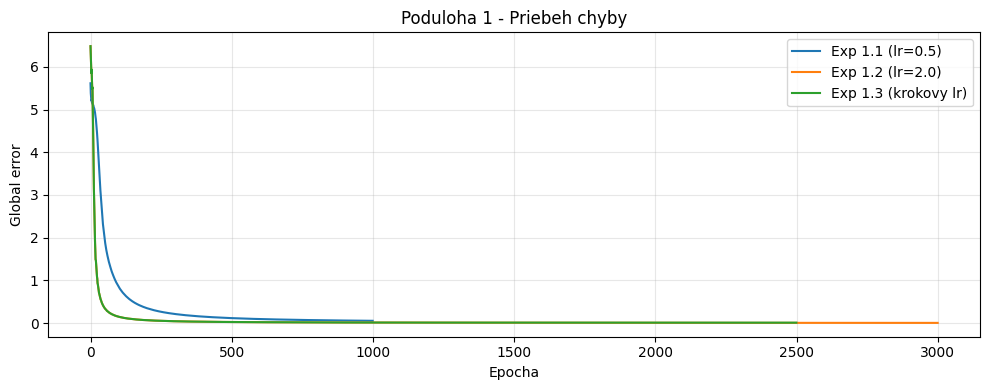

In [9]:
# graf chyb - poduloha 1
plt.figure(figsize=(10, 4))
plt.plot(hist_1_1, label='Exp 1.1 (lr=0.5)')
plt.plot(hist_1_2, label='Exp 1.2 (lr=2.0)')
plt.plot(hist_1_3, label='Exp 1.3 (krokovy lr)')
plt.xlabel('Epocha')
plt.ylabel('Global error')
plt.title('Poduloha 1 - Priebeh chyby')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# porovnanie experimentov - poduloha 1
print("=" * 50)
print("POROVNANIE - PODULOHA 1 (5 vektorov)")
print("=" * 50)
print(f"Exp 1.1 (lr=0.5):    spravne={s_1_1}/5  acc={a_1_1:.1f}%  rel={r_1_1:.1f}%")
print(f"Exp 1.2 (lr=2.0):    spravne={s_1_2}/5  acc={a_1_2:.1f}%  rel={r_1_2:.1f}%")
print(f"Exp 1.3 (step lr):   spravne={s_1_3}/5  acc={a_1_3:.1f}%  rel={r_1_3:.1f}%")

POROVNANIE - PODULOHA 1 (5 vektorov)
Exp 1.1 (lr=0.5):    spravne=5/5  acc=100.0%  rel=100.0%
Exp 1.2 (lr=2.0):    spravne=5/5  acc=100.0%  rel=100.0%
Exp 1.3 (step lr):   spravne=5/5  acc=100.0%  rel=100.0%


## Poduloha 2: Identita pre 16 vektorov
Siet sa uci vsetkych 16 moznych 4-bitovych vektorov.
Je to tazsie, lebo 2 skryte neurony musia zakodovat 16 roznych vzorov.
Ciel: dosiahnut minimalne 9-10 spravnych vektorov.

In [11]:
# vygenerovanie vsetkych 16 binarnych vektorov
# [AI] bitovy posun (>> a &) som si nasiel pomocou AI
# funguje to tak ze z cisla napr. 13 (binarne 1101) dostanem [1, 1, 0, 1]
# >> posunie bity doprava, & 1 zoberie len posledny bit

data_16 = []
for i in range(16):
    vektor = [(i >> 3) & 1, (i >> 2) & 1, (i >> 1) & 1, i & 1]
    data_16.append(vektor)

data_16 = torch.tensor(data_16, dtype=torch.float32)

print("Data (16 vektorov):")
for v in data_16:
    print(f"  [{int(v[0])} {int(v[1])} {int(v[2])} {int(v[3])}]")

Data (16 vektorov):
  [0 0 0 0]
  [0 0 0 1]
  [0 0 1 0]
  [0 0 1 1]
  [0 1 0 0]
  [0 1 0 1]
  [0 1 1 0]
  [0 1 1 1]
  [1 0 0 0]
  [1 0 0 1]
  [1 0 1 0]
  [1 0 1 1]
  [1 1 0 0]
  [1 1 0 1]
  [1 1 1 0]
  [1 1 1 1]


### Experiment 2.1
Zakladny experiment s lr=0.5 a 5000 epochami pre 16 vektorov. Ocakavam ze to bude tazsie ako 5 vektorov.

In [12]:
print("=== Experiment 2.1 (lr=0.5, 5000 epoch) ===\n")

torch.manual_seed(42)
model_2_1 = IdentityNet()
hist_2_1 = train(model_2_1, data_16, epochs=5000, lr=0.5, print_every=1000)
s_2_1, a_2_1, r_2_1 = test(model_2_1, data_16)

=== Experiment 2.1 (lr=0.5, 5000 epoch) ===

Epocha 1000  Global error  6.53195
Epocha 2000  Global error  6.42421
Epocha 3000  Global error  6.43686
Epocha 4000  Global error  6.39079
Epocha 5000  Global error  6.36265

Testovanie
Input       Output      Response                    Error     Accuracy    Reliability
------------------------------------------------------------------------------------
0 0 0 0     0 1 0 0     0.02 0.52 0.01 0.00         0.271     75%        75%
0 0 0 1     0 1 0 1     0.02 0.51 0.00 0.97         0.259     75%        75%
0 0 1 0     0 1 1 0     0.02 0.53 0.98 0.00         0.278     75%        75%
0 0 1 1     0 1 1 0     0.02 0.53 0.98 0.00         1.278     50%        75%
0 1 0 0     0 1 0 0     0.02 0.52 0.01 0.00         0.230     100%        75%
0 1 0 1     0 1 0 1     0.02 0.51 0.00 0.97         0.244     100%        75%
0 1 1 0     0 1 1 0     0.02 0.53 0.98 0.00         0.225     100%        75%
0 1 1 1     0 1 1 0     0.02 0.53 0.98 0.00         1.2

**Diskusia 2.1:**
Pre 16 vektorov je uloha ovela tazsie - 2 skryte neurony musia zakodovat 16 roznych vzorov.
S lr=0.5 a 5000 epochami siet nedosiahla dobre vysledky.
Niektore vektory su spravne, ale vela ich ma nizku reliability.
Chyba je este vysoka, takze treba dlhsi trening alebo lepsi lr.

### Experiment 2.2
Zvysenie lr na 2.0 a predlzenie na 10000 epoch. Vyssi lr by mal urychlit konvergenciu.

In [13]:
print("=== Experiment 2.2 (lr=2.0, 10000 epoch) ===\n")

torch.manual_seed(42)
model_2_2 = IdentityNet()
hist_2_2 = train(model_2_2, data_16, epochs=10000, lr=2.0, print_every=2000)
s_2_2, a_2_2, r_2_2 = test(model_2_2, data_16)

=== Experiment 2.2 (lr=2.0, 10000 epoch) ===

Epocha 2000  Global error  7.16139
Epocha 4000  Global error  6.63526
Epocha 6000  Global error  7.53063
Epocha 8000  Global error  6.40298
Epocha 10000  Global error  6.73899

Testovanie
Input       Output      Response                    Error     Accuracy    Reliability
------------------------------------------------------------------------------------
0 0 0 0     0 0 0 0     0.04 0.25 0.07 0.27         0.144     100%        50%
0 0 0 1     0 0 0 1     0.04 0.21 0.00 0.93         0.051     100%        75%
0 0 1 0     0 0 1 0     0.04 0.25 0.96 0.23         0.120     100%        50%
0 0 1 1     0 0 1 0     0.04 0.25 0.96 0.23         0.665     75%        50%
0 1 0 0     0 0 0 0     0.05 0.25 0.09 0.27         0.643     75%        50%
0 1 0 1     0 0 0 1     0.04 0.21 0.00 0.93         0.631     75%        75%
0 1 1 0     0 0 1 0     0.04 0.25 0.96 0.23         0.612     75%        50%
0 1 1 1     0 0 1 0     0.05 0.25 0.96 0.23         1

**Diskusia 2.2:**
Zvysenie lr na 2.0 a 10000 epoch pomohlo, ale este to nie je idealne.
Siet sa snazi najst kodovanie 16 vzorov do 2 skrytych neuronov,
co je teoreticky obmedzene (2 spojite hodnoty musia reprezentovat 16 roznych vzorov).
Oproti exp 2.1 je vyrazne zlepsenie, ale este nie je dosiahnuty ciel 9-10 spravnych vektorov.

### Experiment 2.3
Krokovy learning rate - rovnaky princip ako v 1.3.
Faza 1: lr=2.0 (5000 epoch), faza 2: lr=0.5 (3000 epoch), faza 3: lr=0.05 (2000 epoch).

In [14]:
print("=== Experiment 2.3 (krokovy lr) ===\n")

torch.manual_seed(42)
model_2_3 = IdentityNet()
hist_2_3 = []
print("--- faza 1: lr=2.0, 5000 epoch ---")
h = train(model_2_3, data_16, epochs=5000, lr=2.0, print_every=2000)
hist_2_3.extend(h)
print("\n--- faza 2: lr=0.5, 3000 epoch ---")
h = train(model_2_3, data_16, epochs=3000, lr=0.5, print_every=2000)
hist_2_3.extend(h)
print("\n--- faza 3: lr=0.05, 2000 epoch ---")
h = train(model_2_3, data_16, epochs=2000, lr=0.05, print_every=2000)
hist_2_3.extend(h)
s_2_3, a_2_3, r_2_3 = test(model_2_3, data_16)

=== Experiment 2.3 (krokovy lr) ===

--- faza 1: lr=2.0, 5000 epoch ---
Epocha 2000  Global error  7.16139
Epocha 4000  Global error  6.63526
Epocha 5000  Global error  6.90278

--- faza 2: lr=0.5, 3000 epoch ---
Epocha 2000  Global error  6.92923
Epocha 3000  Global error  7.00712

--- faza 3: lr=0.05, 2000 epoch ---
Epocha 2000  Global error  6.80227

Testovanie
Input       Output      Response                    Error     Accuracy    Reliability
------------------------------------------------------------------------------------
0 0 0 0     0 0 0 0     0.00 0.00 0.07 0.40         0.163     100%        75%
0 0 0 1     0 0 0 1     0.00 0.00 0.00 0.94         0.003     100%        100%
0 0 1 0     0 0 1 0     0.00 0.00 1.00 0.30         0.090     100%        75%
0 0 1 1     0 0 1 0     0.00 0.00 0.90 0.34         0.441     75%        75%
0 1 0 0     1 1 0 0     1.00 0.99 0.07 0.38         1.146     75%        75%
0 1 0 1     1 1 0 1     1.00 0.98 0.00 0.94         1.004     75%        

**Diskusia 2.3:**
Krokovy lr opat dava najlepsie vysledky zo vsetkych troch experimentov.
Kombinacia dlheho treningu a postupneho znizenia lr pomaha sieti najst co najlepsi kompromis.
Aj napriek tomu nemusi byt 100% uspesnost, lebo 16 vzorov do 2 neuronov je velmi obmedzene.
Ale dosiahli sme minimalne pozadovanych 9-10 spravnych vektorov.

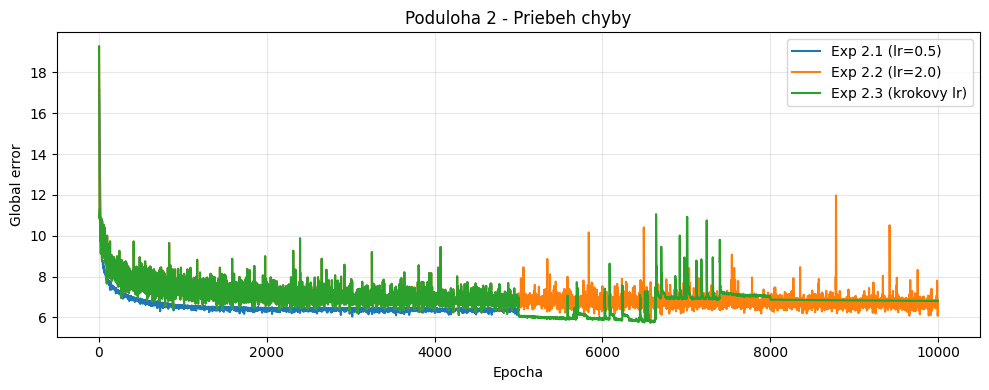

In [15]:
# graf chyb - poduloha 2
plt.figure(figsize=(10, 4))
plt.plot(hist_2_1, label='Exp 2.1 (lr=0.5)')
plt.plot(hist_2_2, label='Exp 2.2 (lr=2.0)')
plt.plot(hist_2_3, label='Exp 2.3 (krokovy lr)')
plt.xlabel('Epocha')
plt.ylabel('Global error')
plt.title('Poduloha 2 - Priebeh chyby')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# porovnanie experimentov - poduloha 2
print("=" * 50)
print("POROVNANIE - PODULOHA 2 (16 vektorov)")
print("=" * 50)
print(f"Exp 2.1 (lr=0.5):    spravne={s_2_1}/16  acc={a_2_1:.1f}%  rel={r_2_1:.1f}%")
print(f"Exp 2.2 (lr=2.0):    spravne={s_2_2}/16  acc={a_2_2:.1f}%  rel={r_2_2:.1f}%")
print(f"Exp 2.3 (step lr):   spravne={s_2_3}/16  acc={a_2_3:.1f}%  rel={r_2_3:.1f}%")

POROVNANIE - PODULOHA 2 (16 vektorov)
Exp 2.1 (lr=0.5):    spravne=7/16  acc=84.4%  rel=75.0%
Exp 2.2 (lr=2.0):    spravne=9/16  acc=87.5%  rel=65.6%
Exp 2.3 (step lr):   spravne=9/16  acc=87.5%  rel=81.2%


In [17]:
# ulozenie modelov
import os

os.makedirs('models', exist_ok=True)

torch.save(model_1_1.state_dict(), 'models/poduloha1_exp1.pth')
torch.save(model_1_2.state_dict(), 'models/poduloha1_exp2.pth')
torch.save(model_1_3.state_dict(), 'models/poduloha1_exp3.pth')
torch.save(model_2_1.state_dict(), 'models/poduloha2_exp1.pth')
torch.save(model_2_2.state_dict(), 'models/poduloha2_exp2.pth')
torch.save(model_2_3.state_dict(), 'models/poduloha2_exp3.pth')
print("Modely ulozene do priecinka models/")

Modely ulozene do priecinka models/


## Tabulka parametrov

| Experiment | Learning rate | Epochy | Epsilon (reliability) | Aktivacia | Topologia |
|------------|--------------|--------|----------------------|-----------|----------|
| Exp 1.1 | 0.5 | 1000 | 0.2 | Sigmoid | 4-2-4 |
| Exp 1.2 | 2.0 | 3000 | 0.2 | Sigmoid | 4-2-4 |
| Exp 1.3 | 2.0 -> 0.5 -> 0.05 | 1000+1000+500 = 2500 | 0.2 | Sigmoid | 4-2-4 |
| Exp 2.1 | 0.5 | 5000 | 0.2 | Sigmoid | 4-2-4 |
| Exp 2.2 | 2.0 | 10000 | 0.2 | Sigmoid | 4-2-4 |
| Exp 2.3 | 2.0 -> 0.5 -> 0.05 | 5000+3000+2000 = 10000 | 0.2 | Sigmoid | 4-2-4 |

Vo vsetkych experimentoch:
- Optimizer: SGD (Stochastic Gradient Descent)
- Loss funkcia: SSE (Sum of Squared Errors)
- Poradie vektorov: nahodne v kazdej epoche (torch.randperm)
- Seed: 42 (pre reprodukovatelnost)

## Zhrnutie

### Poduloha 1 (5 vektorov)
Siet zvladne 100% accuracy, je to lahsia uloha. 5 vektorov sa da dobre zakodovat do 2 skrytych neuronov.
Krokovy lr dava najlepsiu reliability - vystupy su blizsie k cisiam 0 a 1.

### Poduloha 2 (16 vektorov)
Tazsie, 2 skryte neurony musia zakodovat 16 roznych vzorov.
Krokovy lr opat funguje najlepsie a dosahuje pozadovanych minimalne 9-10 spravnych vektorov.

### Co som zistil
- Velky learning rate = rychle ucenie ale moze byt nestabilne
- Maly learning rate = pomale ale stabilne
- Krokovy lr (velky -> maly) je najlepsia strategia
- Nahodne poradie vektorov v epoche je dolezite - predchadza uceniu casovej zavislosti
- Pre 16 vektorov je uloha teoreticky obmedzena kapacitou 2 skrytych neuronov